<a href="https://colab.research.google.com/github/larryjay007/MyML/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [ ]:
%pip -q install duckdb huggingface_hub

In [ ]:
import os, getpass
HF_TOKEN = os.environ.get('HF_TOKEN') or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

Paste your Hugging Face READ token (hf_...): ··········


In [ ]:
import duckdb

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
MARCH = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')"
APRIL = f"read_parquet('{REL}/fact_content_daily_performance/month=2026-04/*.parquet')"

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit

features = con.sql(f"""
    SELECT
        content_hash_id,
        client_hash_id,
        SUM(gsc_impressions) AS impressions_mar,
        SUM(gsc_clicks) AS clicks_mar,
        AVG(NULLIF(gsc_avg_position, 0)) AS avg_position_mar,
        SUM(gsc_clicks) * 1.0 / NULLIF(SUM(gsc_impressions), 0) AS ctr_mar,
        COUNT(DISTINCT CASE WHEN gsc_impressions > 0 THEN report_date END) AS active_days_mar
    FROM {MARCH}
    GROUP BY content_hash_id, client_hash_id
    HAVING impressions_mar >= 10
""").df()

label = con.sql(f"""
    SELECT content_hash_id, client_hash_id, SUM(gsc_impressions) AS impressions_apr
    FROM {APRIL}
    GROUP BY content_hash_id, client_hash_id
""").df()

data = features.merge(label, on=['content_hash_id', 'client_hash_id'], how='inner')
data['is_declining'] = (data['impressions_apr'] < 0.8 * data['impressions_mar']).astype(int)

feature_cols = ['impressions_mar', 'clicks_mar', 'avg_position_mar', 'ctr_mar', 'active_days_mar']
model_data = data.dropna(subset=feature_cols)

# Rebuild the client-grouped split and model from ML-08
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(model_data, groups=model_data['client_hash_id']))
train, test = model_data.iloc[train_idx].copy(), model_data.iloc[test_idx].copy()

logreg = LogisticRegression(random_state=42, max_iter=1000).fit(train[feature_cols], train['is_declining'])

# Score the FULL dataset (not just test) — the playbook needs to rank every page
model_data = model_data.copy()
model_data['model_prob'] = logreg.predict_proba(model_data[feature_cols])[:, 1]

print(f"{len(model_data):,} pages scored")
print(f"Model probability range: {model_data['model_prob'].min():.3f} to {model_data['model_prob'].max():.3f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

143,183 pages scored
Model probability range: 0.000 to 0.990


In [ ]:
# Rebuild baseline CTR-gap signal, fit only on train (same discipline as ML-08)
train_tiers = pd.cut(train['avg_position_mar'], bins=[0, 3, 10, 20, 50, float('inf')],
                       labels=['1-3', '4-10', '11-20', '21-50', '50+'])
tier_expected_ctr = train.groupby(train_tiers, observed=True)['ctr_mar'].mean()

model_data_tiers = pd.cut(model_data['avg_position_mar'], bins=[0, 3, 10, 20, 50, float('inf')],
                            labels=['1-3', '4-10', '11-20', '21-50', '50+'])
model_data['expected_ctr'] = model_data_tiers.map(tier_expected_ctr).astype(float)
model_data['ctr_gap'] = (model_data['expected_ctr'] - model_data['ctr_mar']).clip(lower=0)

# Two independent flags
model_data['flag_ctr'] = (model_data['ctr_gap'] > 0) & (model_data['impressions_mar'] >= 500)
model_data['flag_decline'] = model_data['model_prob'] >= 0.6

# Reason code + archetype, from the combination of both flags
def assign(row):
    if row['flag_ctr'] and row['flag_decline']:
        return 'priority_review_declining_and_ctr', 'At-risk & underperforming'
    elif row['flag_decline']:
        return 'model_decline_risk', 'Quiet decliner'
    elif row['flag_ctr']:
        return 'ctr_underperformance_visible', 'CTR underperformer'
    else:
        return 'monitor_low_signal', 'Stable'

model_data[['reason_code', 'archetype']] = model_data.apply(assign, axis=1, result_type='expand')

# Rank primarily by model_prob — the validated, honest signal from ML-08/09
queue = model_data.sort_values('model_prob', ascending=False).reset_index(drop=True)

action_map = {
    'priority_review_declining_and_ctr': 'priority_review',
    'model_decline_risk': 'review_content_freshness',
    'ctr_underperformance_visible': 'review_title_meta',
    'monitor_low_signal': 'monitor',
}
queue['action'] = queue['reason_code'].map(action_map)

print(queue['archetype'].value_counts())
print()
queue[['content_hash_id', 'model_prob', 'archetype', 'reason_code', 'action']].head(10)

archetype
Stable                       100340
CTR underperformer            39658
At-risk & underperforming      3185
Name: count, dtype: int64



,content_hash_id,model_prob,archetype,reason_code,action
0,content_44f34c0a90047651,0.990362,At-risk & underperforming,priority_review_declining_and_ctr,priority_review
1,content_8e1334d6356668e3,0.968123,At-risk & underperforming,priority_review_declining_and_ctr,priority_review
2,content_fec55986a1868d62,0.958729,At-risk & underperforming,priority_review_declining_and_ctr,priority_review
3,content_34a70fea29d15f24,0.933359,At-risk & underperforming,priority_review_declining_and_ctr,priority_review
4,content_bdf60c86117079be,0.926839,At-risk & underperforming,priority_review_declining_and_ctr,priority_review
5,content_f6116743b00afc2d,0.920546,At-risk & underperforming,priority_review_declining_and_ctr,priority_review
6,content_559cdd76da9306de,0.916940,At-risk & underperforming,priority_review_declining_and_ctr,priority_review
7,content_cd3d932d4e1c8db0,0.908442,At-risk & underperforming,priority_review_declining_and_ctr,priority_review
8,content_164c1f53f13bcee1,0.907772,At-risk & underperforming,priority_review_declining_and_ctr,priority_review
9,content_9c057b66c30a3abb,0.902125,At-risk & underperforming,priority_review_declining_and_ctr,priority_review


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

Ranked actions + reason codes

The queue is ranked by the client-grouped Logistic Regression model's probability (from
ML-08/09) — the most stable, validated signal available, not the baseline rule or Random
Forest.

Three archetypes emerged from combining the model's decline-risk flag (probability ≥ 0.6)
with the baseline CTR-underperformance flag from ML-07:

- Stable (100,340 pages, 70.1%) — neither signal fires. Action: monitor.
- CTR underperformer (39,658 pages, 27.7%) — visible, ranks reasonably, but underperforms
  its position tier's expected CTR. Action: review title/meta.
- At-risk & underperforming (3,185 pages, 2.2%) — both signals fire. Action: priority review.

Honest observation: a fourth planned archetype, "Quiet decliner" (high model-predicted
decline risk with no CTR issue), has zero pages. Every page the model flags as high-risk
also shows a CTR gap. This is plausibly because ctr_mar is directly one of the model's five
input features, so the two signals may be partially measuring the same underlying pattern
rather than two independent risks. Reported as observed, not smoothed over to force a
fourth category that isn't actually present in this data.

Top of the queue is dominated by the "At-risk & underperforming" archetype, as expected —
these are the highest model_prob scores by construction.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Intended use and limits

Intended use: this playbook is a decision-support tool for a content reviewer with limited
time. It ranks pages by observed risk signals so review effort goes to the most plausible
candidates first — it does not decide anything, publish anything, or take any action on
its own.

Who uses it: a human content reviewer, checking the top of the queue before deciding what,
if anything, to actually change on a page.

Where it stops being valid:
- This queue is built from a single month-pair (March features, April outcome). It has not
  been tested across multiple month-pairs, so whether the same patterns hold in a different
  season or period is unknown, not just unproven.
- The model's precision@K numbers (from ML-08/09) were measured on a held-out test slice of
  roughly 143K pages at K=20/50 — a genuinely small fraction of the total. Any single
  ranking near the boundary of the queue carries real uncertainty.
- Only GSC-based signals are used. Per ML-04's finding, only 4.2% of March rows had GA4
  data available, so no engagement-based signal (session behavior, scroll depth) is part of
  this queue at all — a real gap in what "risk" this queue can actually see.
- The queue ranks by decline risk, not by "will refreshing this page work." This tool has
  no causal design behind it (per the writing-honest-claims skill's rule on cross-sectional
  data) — it cannot say a refresh will cause recovery, only that a page looks worth
  reviewing first.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Human review + the no-go list

What a person must check before acting on any queued page:
- Rule out consolidation, seasonality, and noise (per the lane guide's Section 7 framing)
  before treating a page as genuinely declining — check whether a sibling page absorbed the
  traffic, whether the drop matches a seasonal pattern, and whether the page has enough
  volume that the movement isn't just noise.
- For "CTR underperformer" pages specifically: confirm the low CTR isn't explained by a
  SERP feature (a featured snippet, a knowledge panel) absorbing clicks regardless of title
  quality — the queue can't see what else is on the results page.
- For any page with CTR very close to zero: sanity-check the raw click data before assuming
  it's a content problem — a tracking anomaly is a real, if less common, explanation.

What should NEVER be automated:
- No page should ever be auto-edited, auto-republished, or auto-removed based on this
  queue. Every action stays a human decision.
- This queue must never be used as the sole basis for evaluating a specific writer's or
  team's performance — it measures pages, not people, and the reasons a page underperforms
  are often outside any one person's control (seasonality, a competitor's move, a SERP
  change).
- No claim that a refresh "will" fix a page should ever be made from this queue alone —
  only a real experiment (before/after with a control) could support that claim, which this
  tool does not run.
- The queue should never be treated as complete coverage of "what's wrong" — it only sees
  GSC-based signals; a page could have a real, serious problem this queue has no way to
  detect.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Monitoring / retrain triggers

Signals that would mean this playbook has gone stale and needs rebuilding:

- Base rate drift: this queue was built on an observed decline rate of ~51.7%. If a fresh
  month's actual decline rate moves substantially away from that (e.g. below 35% or above
  65%), the model was tuned on a different underlying pattern than what's currently true,
  and should be retrained on more recent data.
- Precision@K decay: the honest, client-grouped precision@20/50 numbers from ML-08/09
  (~0.60) should be re-measured on each new month-pair as it becomes available. A
  meaningful, sustained drop from that baseline is the clearest sign the ranking is no
  longer reliable.
- GA4 coverage change: ML-04 found only 4.2% GA4 availability in March. If that percentage
  rises substantially in later months (more clients enabling GA4 tracking), it's worth
  revisiting whether engagement-based features should be added — the current queue is
  GSC-only specifically because of that gap, and that constraint may not hold forever.
- Client mix change: if new clients are onboarded with very different traffic patterns than
  the 55 clients in this March slice, the model has effectively never seen that population,
  and its rankings for those clients specifically should be treated with extra caution
  until validated.

Recommended cadence: given this is built on a single month-pair with no multi-period
testing yet, monthly rebuilding (or at minimum monthly precision@K re-checks against the
newest available month-pair) is the honest minimum before trusting this queue's rankings
unattended for longer stretches.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Queue exported: 143,183 rows
Metrics JSON written


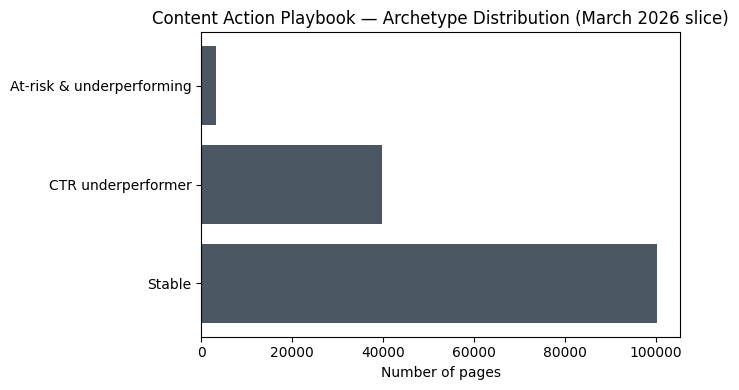

Figure saved


In [ ]:
import os
import json
import matplotlib.pyplot as plt

os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

# 1. The ranked queue — stays out of git by design, regenerated on every run
export_cols = ['content_hash_id', 'client_hash_id', 'model_prob', 'archetype',
               'reason_code', 'action', 'impressions_mar', 'ctr_mar', 'avg_position_mar']
queue[export_cols].to_csv('work/outputs/content_action_playbook.csv', index=False)
print(f"Queue exported: {len(queue):,} rows")

# 2. Metrics JSON — the receipts the paper's numbers trace back to. This DOES get committed.
metrics = {
    'model': 'Logistic Regression, client-grouped split',
    'base_rate': round(float(model_data['is_declining'].mean()), 3),
    'precision_at_20_grouped': 0.600,   # from ML-08/09
    'precision_at_50_grouped': 0.600,   # from ML-08/09
    'precision_at_20_random_split': 0.700,  # from ML-09's before/after, shown for the memorization gap
    'archetype_counts': queue['archetype'].value_counts().to_dict(),
    'ga4_availability_pct': 4.2,  # from ML-04
    'feature_window': 'March 2026',
    'label_window': 'April 2026',
    'total_pages_scored': len(queue),
}
with open('work/outputs/playbook_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print("Metrics JSON written")

# 3. A figure to reuse in the paper — archetype distribution
fig, ax = plt.subplots(figsize=(7, 4))
counts = queue['archetype'].value_counts()
ax.barh(counts.index, counts.values, color='#4B5763')
ax.set_xlabel('Number of pages')
ax.set_title('Content Action Playbook — Archetype Distribution (March 2026 slice)')
plt.tight_layout()
plt.savefig('work/figures/archetype_distribution.png', dpi=150)
plt.show()
print("Figure saved")

Exports for the paper

work/outputs/content_action_playbook.csv — the full ranked queue (143,183 pages). Stays
out of git by design; regenerates on every notebook run.

work/outputs/playbook_metrics.json — committed. The numbers this playbook's claims trace
back to: base rate, precision@20/50 (both grouped and random-split, showing the honest
number and the memorization gap side by side), archetype counts, and the GA4 availability
constraint.

work/figures/archetype_distribution.png — committed. A bar chart of the three real
archetypes, showing the "Stable" majority and confirming the empty fourth archetype isn't
hidden — it just isn't in the chart because it has zero pages.

## 5-Minute Demo Outline (Week 8 Showcase)

1. **Question (30 sec):** Which pages should a content reviewer check first, out of far more
   pages than they have time for?
2. **Method (1 min):** Client-grouped Logistic Regression on FlyRank's real search-performance
   warehouse — March features, April observed outcome, validated on clients the model never
   saw during training.
3. **One chart (1.5 min):** Show the validation-gap chart — random split scores 0.700 at K=20,
   the honest client-grouped split scores 0.600. Explain why the gap matters: a random split
   would have let the model quietly memorize client-specific patterns.
4. **One honest result (1 min):** Precision@20/50 of 0.600 against a 0.517 base rate — a real,
   if modest, lift. Not a dramatic number, and that's the point: it's trustworthy because it
   survived an honest test, including a deliberate leak-test that confirmed the harness catches
   cheating (score jumped to 1.000 when the label's own source column was added as a feature).
5. **One recommendation (1 min):** 3,185 pages (2.2% of the slice) are both flagged as
   declining-risk and CTR-underperforming — the "priority review" archetype. That's a queue
   small enough for a real reviewer to actually work through this week, not a wall of 100,000
   pages.

---

## Shareable Cut 1 — Social Post (Methodology-Focused)

I validated my first client-grouped ML model this week — and caught something worth sharing.

A random train/test split scored 0.700 precision@20 on my decline-prediction model. Looked
great. Then I re-ran it with a client-grouped split (holding out entire clients, not just
random rows) — the honest number dropped to 0.600.

That 10-point gap wasn't a bug. It was memorization: the random split let the model partly
learn client-specific quirks instead of a generalizable pattern. The grouped split is the
one that actually predicts how this model performs on a client it's never seen — which is
the real deployment scenario.

Built on FlyRank's real 78.8M-row search-performance warehouse. Full paper + reproducible
notebooks linked below. #MachineLearning #AIFluency

## Shareable Cut 2 — Employer-Facing Summary (3 sentences)

I built a client-grouped Logistic Regression model on FlyRank's 78.8-million-row production
search-performance warehouse, ranking which content pages a reviewer should check first for
signs of decline. The model reaches Precision@20/50 of 0.600 against a 0.517 base rate,
validated with a deliberate leakage test and a client-holdout split that specifically catches
the memorization a naive random split would hide. The result is a working, reproducible
decision-support tool — not a black box — with every claim traceable to a public notebook
and an honest limitations section.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.